In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [33]:
df = pd.read_csv("/content/hospital_navigation_dataset.csv")

print(df.head())
print("Dataset Shape:", df.shape)

ROWS = int(df["Row"].max()) + 1
COLS = int(df["Column"].max()) + 1

START = tuple(
    df.loc[df["Cell_Type"] == "START", ["Row", "Column"]]
    .iloc[0]
    .astype(int)
)

GOAL = tuple(
    df.loc[df["Cell_Type"] == "GOAL", ["Row", "Column"]]
    .iloc[0]
    .astype(int)
)

OBSTACLES = set(
    map(
        tuple,
        df.loc[
            df["Cell_Type"] == "OBSTACLE",
            ["Row", "Column"]
        ].astype(int).values
    )
)

print("Grid Size:", ROWS, "x", COLS)
print("Start:", START)
print("Goal:", GOAL)
print("Obstacles:", len(OBSTACLES))

   Row  Column Cell_Type  Reward
0    0       0     START      -1
1    0       1      FREE      -1
2    0       2  OBSTACLE     -10
3    0       3  OBSTACLE     -10
4    0       4      FREE      -1
Dataset Shape: (100, 4)
Grid Size: 10 x 10
Start: (0, 0)
Goal: (9, 9)
Obstacles: 28


In [34]:
ACTIONS = [
    (-1, 0),
    (1, 0),
    (0, -1),
    (0, 1)
]

NUM_ACTIONS = 4

In [35]:
states = [
    (r, c)
    for r in range(ROWS)
    for c in range(COLS)
]

state_to_index = {
    state: i
    for i, state in enumerate(states)
}

NUM_STATES = len(states)

In [36]:
def step(state, action):

    row, col = state
    dr, dc = ACTIONS[action]

    new_row = row + dr
    new_col = col + dc

    new_state = (new_row, new_col)

    # Outside grid
    if (
        new_row < 0
        or new_row >= ROWS
        or new_col < 0
        or new_col >= COLS
    ):
        return state, -5, False

    # Obstacle
    if new_state in OBSTACLES:
        return state, -10, False

    # Goal
    if new_state == GOAL:
        return new_state, 100, True

    return new_state, -1, False

In [37]:
EPISODES = 1500
MAX_STEPS = 150

LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.95

EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.995


In [38]:
def choose_action(q_table, state, epsilon):

    state_index = state_to_index[state]

    if random.random() < epsilon:
        return random.randint(0, NUM_ACTIONS - 1)

    return np.argmax(q_table[state_index])

In [39]:
def train_q_learning():

    q_table = np.zeros(
        (NUM_STATES, NUM_ACTIONS)
    )

    rewards = []
    steps_history = []
    success_history = []

    epsilon = EPSILON_START

    for episode in range(EPISODES):

        state = START
        total_reward = 0
        success = 0

        for step_count in range(MAX_STEPS):

            action = choose_action(
                q_table,
                state,
                epsilon
            )

            next_state, reward, done = step(
                state,
                action
            )

            state_index = state_to_index[state]
            next_index = state_to_index[next_state]

            if done:
                target = reward

            else:
                target = (
                    reward
                    + DISCOUNT_FACTOR
                    * np.max(q_table[next_index])
                )

            q_table[state_index, action] += (
                LEARNING_RATE
                * (
                    target
                    - q_table[state_index, action]
                )
            )

            state = next_state
            total_reward += reward

            if done:
                success = 1
                break

        rewards.append(total_reward)

        steps_history.append(
            step_count + 1
        )

        success_history.append(success)

        epsilon = max(
            EPSILON_MIN,
            epsilon * EPSILON_DECAY
        )

    return (
        q_table,
        rewards,
        steps_history,
        success_history
    )

In [40]:
def train_sarsa():

    q_table = np.zeros(
        (NUM_STATES, NUM_ACTIONS)
    )

    rewards = []
    steps_history = []
    success_history = []

    epsilon = EPSILON_START

    for episode in range(EPISODES):

        state = START

        action = choose_action(
            q_table,
            state,
            epsilon
        )

        total_reward = 0
        success = 0

        for step_count in range(MAX_STEPS):

            next_state, reward, done = step(
                state,
                action
            )

            state_index = state_to_index[state]
            next_index = state_to_index[next_state]

            if done:
                target = reward

            else:

                next_action = choose_action(
                    q_table,
                    next_state,
                    epsilon
                )

                target = (
                    reward
                    + DISCOUNT_FACTOR
                    * q_table[
                        next_index,
                        next_action
                    ]
                )

            q_table[state_index, action] += (
                LEARNING_RATE
                * (
                    target
                    - q_table[state_index, action]
                )
            )

            state = next_state
            total_reward += reward

            if done:
                success = 1
                break

            action = next_action

        rewards.append(total_reward)

        steps_history.append(
            step_count + 1
        )

        success_history.append(success)

        epsilon = max(
            EPSILON_MIN,
            epsilon * EPSILON_DECAY
        )

    return (
        q_table,
        rewards,
        steps_history,
        success_history
    )


In [41]:
print("Training Q-Learning...")

q_table, q_rewards, q_steps, q_success = (
    train_q_learning()
)

print("Q-Learning Completed")


print("\nTraining SARSA...")

sarsa_table, sarsa_rewards, sarsa_steps, sarsa_success = (
    train_sarsa()
)

print("SARSA Completed")

Training Q-Learning...
Q-Learning Completed

Training SARSA...
SARSA Completed


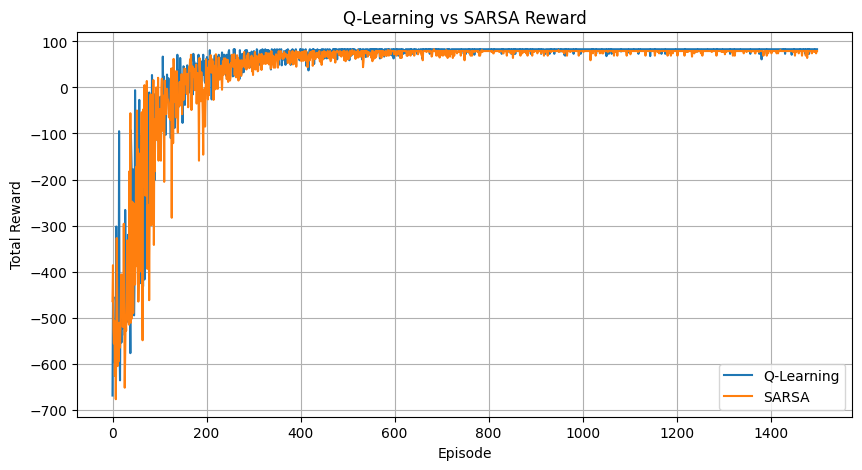

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(
    q_rewards,
    label="Q-Learning"
)

plt.plot(
    sarsa_rewards,
    label="SARSA"
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")

plt.title(
    "Q-Learning vs SARSA Reward"
)

plt.legend()
plt.grid()

plt.show()

In [43]:
q_success_rate = (
    np.mean(q_success) * 100
)

sarsa_success_rate = (
    np.mean(sarsa_success) * 100
)

print(
    "Q-Learning Success Rate:",
    round(q_success_rate, 2),
    "%"
)

print(
    "SARSA Success Rate:",
    round(sarsa_success_rate, 2),
    "%"
)

Q-Learning Success Rate: 97.07 %
SARSA Success Rate: 96.53 %


In [44]:
q_avg_steps = np.mean(
    q_steps[-100:]
)

sarsa_avg_steps = np.mean(
    sarsa_steps[-100:]
)

print(
    "Q-Learning Average Steps:",
    round(q_avg_steps, 2)
)

print(
    "SARSA Average Steps:",
    round(sarsa_avg_steps, 2)
)

Q-Learning Average Steps: 18.19
SARSA Average Steps: 22.18


In [45]:
def get_best_path(q_table):

    state = START

    path = [state]

    visited = set()

    for i in range(MAX_STEPS):

        if state == GOAL:
            break

        if state in visited:
            break

        visited.add(state)

        state_index = state_to_index[state]

        action = np.argmax(
            q_table[state_index]
        )

        next_state, reward, done = step(
            state,
            action
        )

        if next_state == state:
            break

        path.append(next_state)

        state = next_state

        if done:
            break

    return path


q_path = get_best_path(q_table)

sarsa_path = get_best_path(
    sarsa_table
)

print("\nQ-Learning Path:")
print(q_path)

print("\nSARSA Path:")
print(sarsa_path)


Q-Learning Path:
[(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (3, 3), (4, 3), (4, 4), (4, 5), (5, 5), (6, 5), (6, 6), (6, 7), (7, 7), (7, 8), (7, 9), (8, 9), (9, 9)]

SARSA Path:
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (8, 0), (9, 0), (9, 1), (9, 2), (8, 2), (7, 2), (7, 3), (7, 4), (8, 4), (9, 4), (9, 5), (9, 6), (9, 7), (9, 8), (9, 9)]


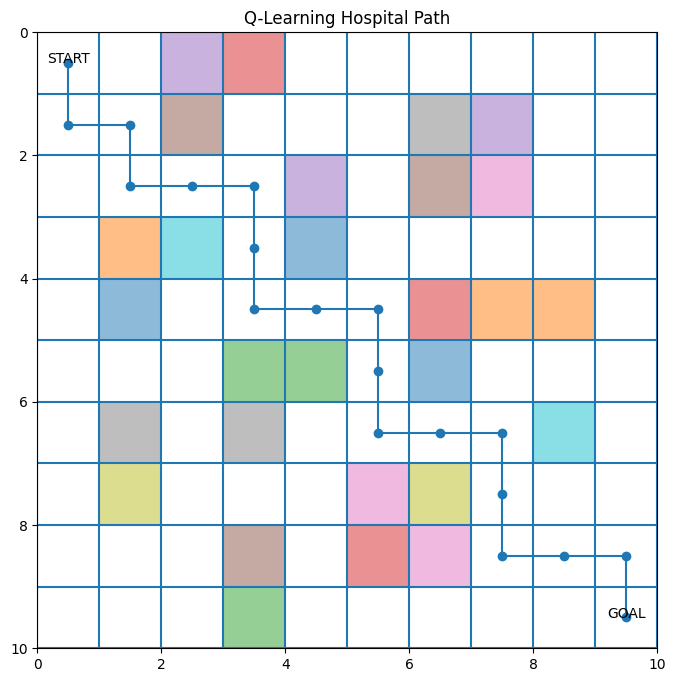

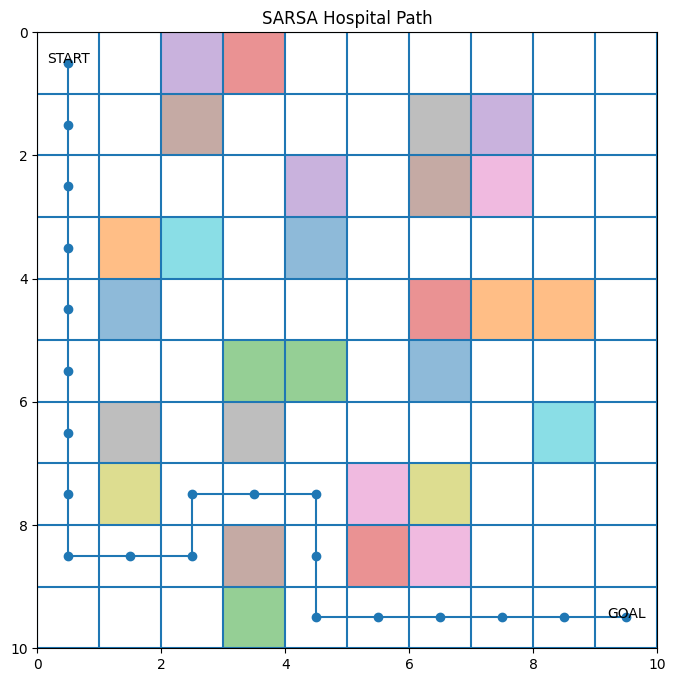

In [30]:
def draw_hospital(path, title):

    plt.figure(figsize=(8, 8))

    for x in range(COLS + 1):
        plt.axvline(x)

    for y in range(ROWS + 1):
        plt.axhline(y)

    # Obstacles
    for r, c in OBSTACLES:

        plt.fill_between(
            [c, c + 1],
            r,
            r + 1,
            alpha=0.5
        )

    # Path
    path_x = [
        c + 0.5
        for r, c in path
    ]

    path_y = [
        r + 0.5
        for r, c in path
    ]

    plt.plot(
        path_x,
        path_y,
        marker="o"
    )

    # Start
    plt.text(
        START[1] + 0.5,
        START[0] + 0.5,
        "START",
        ha="center"
    )

    # Goal
    plt.text(
        GOAL[1] + 0.5,
        GOAL[0] + 0.5,
        "GOAL",
        ha="center"
    )

    plt.xlim(0, COLS)
    plt.ylim(ROWS, 0)

    plt.title(title)

    plt.show()


draw_hospital(
    q_path,
    "Q-Learning Hospital Path"
)

draw_hospital(
    sarsa_path,
    "SARSA Hospital Path"
)

In [31]:
if q_success_rate > sarsa_success_rate:

    print(
        "\nBEST MODEL: Q-Learning"
    )

elif sarsa_success_rate > q_success_rate:

    print(
        "\nBEST MODEL: SARSA"
    )

else:

    print(
        "\nBoth models have similar performance"
    )


BEST MODEL: Q-Learning
